In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          4.84313612  0.          0.
  0.          0.         -1.50046229  0.          0.          0.
  0.          0.          0.         -8.24601537  0.         -1.56670347
  0.          0.          3.59434365  0.         -2.95706303  0.
  0.          0.          7.16864507  0.          0.         -6.51835365
  0.          0.          0.          0.          0.          0.
  0.          1.00079185  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  5.26738719  0.        ]


21.874303886697408

In [39]:
from sklearn.linear_model import Lasso

def lasso_force_sampling(T, L, error_std, Y_t, X_t, beta_star, q):
    """
    Implements the LASSO force sampling algorithm.

    Args:
    - T (int): Total time steps.
    - L (float): Constraint for feature values.
    - error_std (float): Standard deviation of the noise.
    - Y_t (array): Initial observed rewards.
    - X_t (array): Initial feature matrix.
    - beta_star (array): True parameter vector.
    - q (int): Length of the special sampling interval after powers of 2.

    Returns:
    - Y_t (array): Updated observed rewards.
    - X_t (array): Updated feature matrix.
    - Y_t_exp (array): Expected rewards over time.
    - l_2_error_parameter (array): L2 errors of estimated parameters.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t.copy()
    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lambda_value = (np.count_nonzero(beta_star) / 2) * np.sqrt((np.log(tau) + np.log(n_features)) / (tau))

        # Check if tau belongs to the interval [2^n, 2^n + q)
        n = int(np.floor(np.log2(tau)))
        if 2**n <= tau < 2**n + q:
            # Randomly generate X_max within the constraints
            X_max = np.random.uniform(0, L, size=n_features)
            X_max[0] = 1  # Ensure the first feature is set to 1
            #print("random")
        else:
            # Perform LASSO regression
            lasso = Lasso(alpha=lambda_value, fit_intercept=False)
            lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
            beta_esti = lasso.coef_  # Estimated beta values

            # Compute parameter L2 error
            l2_error = np.sqrt(np.sum((beta_esti - beta_star) ** 2))
            #print(f"Parameter L2 error: {l2_error}")
            l_2_error_parameter = np.append(l_2_error_parameter, l2_error)

            # Estimate support size
            s_esti = np.count_nonzero(beta_esti)

            # Optimization to find X_max
            X_max = optimization_no_variance(beta_esti, s_esti, X_t, L, lambda_value, tau)

        # Generate Y_max
        Y_max_exp = beta_star @ X_max
        Y_max = Y_max_exp + np.random.normal(0, error_std, 1)[0]

        #print(f"Time {tau}: Mean reward {Y_max_exp}")

        # Update Y_t and X_t with new data point
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])
        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [40]:
def optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [41]:
def while_force_samping_lasso(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    q = 20
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = lasso_force_sampling(T, L, error_std, Y_t, X_t, beta_star, q)

    return Y_t_exp_no, l_2_error_parameter

In [42]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_force_samping_lasso(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

In [43]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [   21.06573675    43.47215256    67.41104235 ... 17377.01406514
 17387.32801982 17396.15718699]
Cumulative Regret Std: [  2.49017803   4.8635174    4.64411782 ... 783.35958944 784.90606701
 786.18528937]
L2 Error Parameter Mean: [15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193 15.50637193
 15.50637193 15.

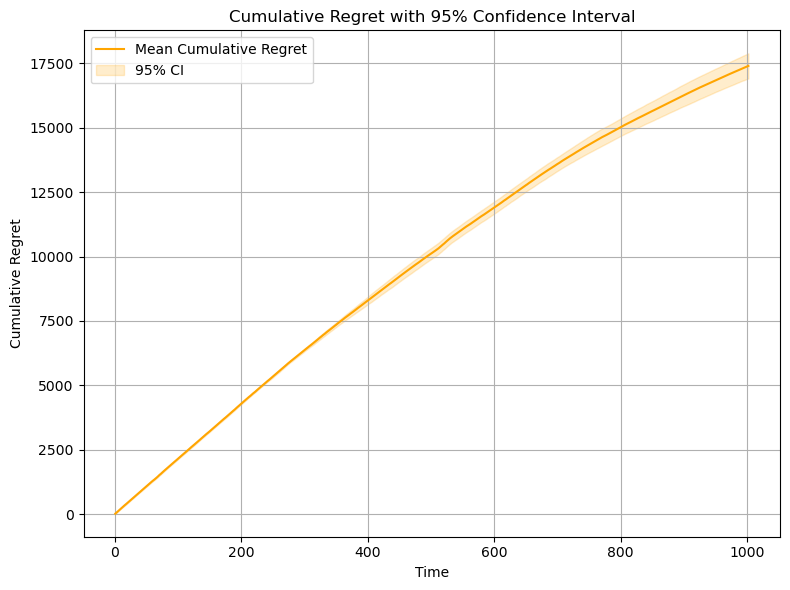

In [44]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [45]:
np.save('cumulative_regret_force-sampling-lasso-bandit-d50-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_force-sampling-lasso-bandit-d50-s10_10times.npy', l_2_error_parameter_times)